# Evaluation Analysis for Recommender Output

In this section we will analyze and compare the generated recommendations and predictions from a predefined list of algorithms with the goal of assessing the performance of each algorithm with respect to a metric. In other words, we would rank the algorithms for each metric considered with respect to performance.

## Setup

Below are the list of packages required to successfully run the analysis. They are divided into partitions to signify their specific task.<br>
We need the pathlib package for working with files and folders

In [1]:
from pathlib import Path
import json

Load libraries for analysis and visualization:

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Import the LensKit metrics for analysis:

In [3]:
from lenskit.data import Dataset, ItemListCollection
from lenskit.metrics import RunAnalysis, RMSE, NDCG, RecipRank, RBP

In [4]:
from lkdemo.datasets import split_fraction

## Load Data

The recommendations are in `runs`, and we will need to reassemble the test data from `test`.

In [5]:
dataset = "ml-100k"

In [6]:
# Parameters
dataset = "ml-100k"


In [7]:
output_root = Path("runs")
run_dir = output_root / dataset

In [8]:
dirs = [rd for rd in run_dir.iterdir() if rd.is_dir()]

In [9]:
recs = ItemListCollection(['model', 'user_id'], index=False)
for fld in dirs:
    for file in fld.glob("recs-*"):
        rec = ItemListCollection.load_parquet(file)
        recs.add_from(rec, model=fld.name)

In [10]:
rec_algos = sorted(set(a for (a, _u) in recs.keys()))
rec_algos

['als-explicit',
 'als-implicit',
 'bias',
 'flex-bpr',
 'flex-explicit',
 'flex-logistic',
 'flex-warp',
 'iknn-explicit',
 'iknn-implicit',
 'popular',
 'uknn-explicit',
 'uknn-implicit']

In [11]:
preds = ItemListCollection(['model', 'user_id'], index=False)
for fld in dirs:
    for file in fld.glob("pred-*"):
        pred = ItemListCollection.load_parquet(file)
        preds.add_from(pred, model=fld.name)

We need to load the test data so that we have the ground truths for computing accuracy.

In [12]:
data = Dataset.load(f"data/{dataset}")
split = split_fraction(data, 0.2)
test = split.test

And identify users in the training set, so we only report metrics over them.

In [13]:
train_users = split.train.user_stats()
train_users = train_users[train_users['rating_count'] > 0]

## Top-N Metrics

`RunListAnalysis` computes metrics for recommendation results and takes care of
matching recommendations and ground truth.

In [14]:
ra = RunAnalysis()

ra.add_metric(NDCG())
ra.add_metric(RecipRank())
ra.add_metric(RBP())

rec_results = ra.compute(recs, test)
rec_results.list_summary('model')

/home/mde48/lenskit/lk-demo-experiment/.venv/lib/python3.12/site-packages/lenskit/metrics/bulk.py:92: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df = scores.groupby(list(keys)).agg(["mean", "median", "std"]).stack(level=0)


mean    median       std
model                                                
als-explicit  NDCG       0.163501  0.130621  0.121956
              RBP        0.176019  0.075306  0.199986
              RecipRank  0.239936  0.166667  0.267693
als-implicit  NDCG       0.099538  0.076218  0.109621
              RBP        0.046578  0.008047  0.109216
              RecipRank  0.103273  0.045455  0.210439
bias          NDCG       0.163369  0.128442  0.122004
              RBP        0.177391  0.086458  0.195531
              RecipRank  0.228765  0.166667  0.242535
flex-bpr      NDCG       0.068223  0.055229  0.066275
              RBP        0.029506  0.004210  0.082543
              RecipRank  0.069638  0.041667  0.161823
flex-explicit NDCG       0.068379  0.059443  0.066597
              RBP        0.026615  0.003634  0.063902
              RecipRank  0.070937  0.041667  0.149586
flex-logistic NDCG       0.068177  0.058942  0.064139
              RBP        0.028096  0.003577  0.079437
              RecipRank  0.064493  0.040000  0.145496
flex-warp     NDCG       0.068526  0.058942  0.065953
              RBP        0.030376  0.004291  0.085084
              RecipRank  0.070343  0.041667  0.162229
iknn-explicit NDCG       0.027915  0.000000  0.063749
              RBP        0.014224  0.000000  0.055387
              RecipRank  0.036419  0.000000  0.133318
iknn-implicit NDCG       0.051237  0.000000  0.126137
              RBP        0.045462  0.000000  0.150641
              RecipRank  0.077597  0.000000  0.231716
popular       NDCG       0.279687  0.268988  0.162487
              RBP        0.318951  0.250104  0.273319
              RecipRank  0.494082  0.250000  0.409474
uknn-explicit NDCG       0.028353  0.000000  0.057482
              RBP        0.007342  0.000000  0.028046
              RecipRank  0.018191  0.000000  0.051798
uknn-implicit NDCG       0.066480  0.000000  0.146865
              RBP        0.046566  0.000000  0.139570
              RecipRank  0.096589  0.000000  0.255705

We can reshape the list metrics and plot them, after filtering to only users with at least 1 training rating:

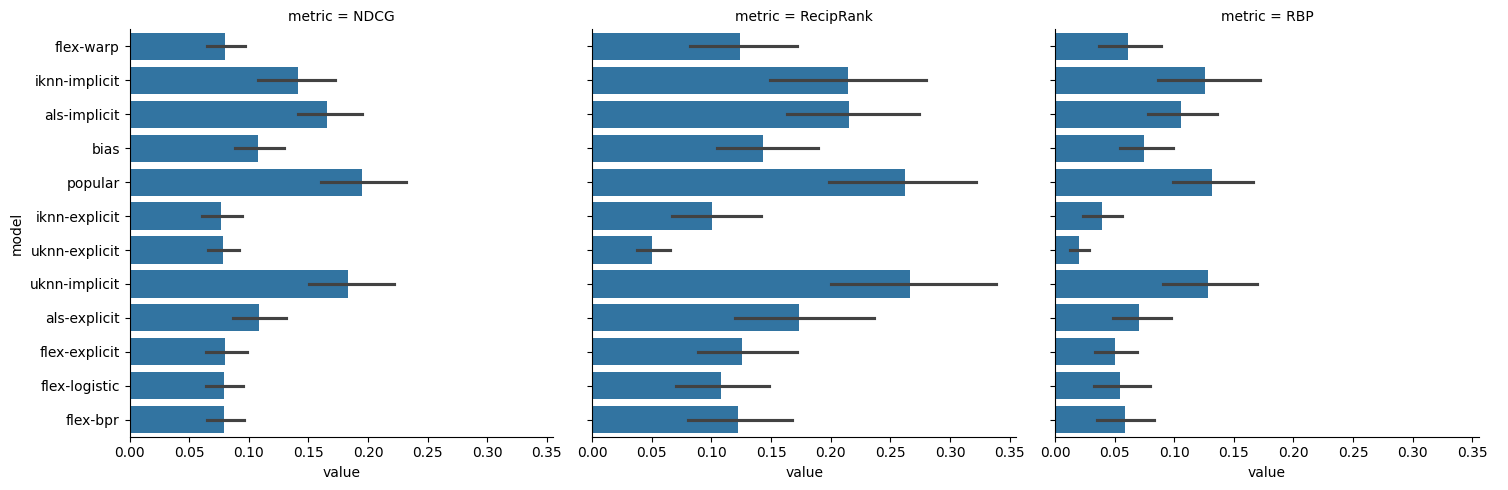

In [15]:
metrics = rec_results.list_metrics()
metrics = metrics.melt(var_name='metric', ignore_index=False).reset_index()
metrics = metrics[metrics['user_id'].isin(train_users.index)]
sns.catplot(metrics, y='model', x='value', col='metric', kind='bar')
plt.show()

Let's look at the influence of training ratings on performance, clamping 15+
into a single category — this helps understand perhaps surprising performance
relative to cross-fold evaluations:

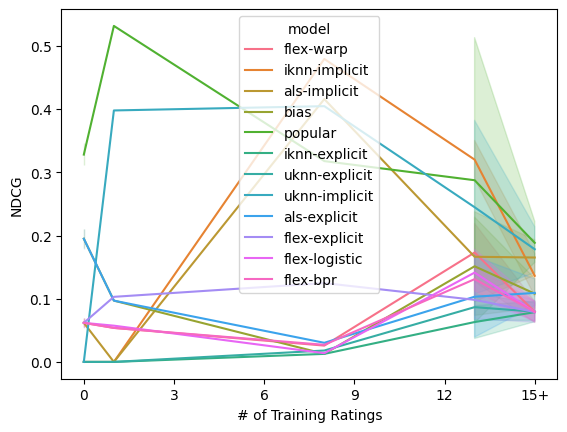

In [16]:
tcounts = split.train.user_stats()['rating_count'].copy()
tcounts[tcounts > 15] = 15
metrics = rec_results.list_metrics().reset_index().join(tcounts, on='user_id')
sns.lineplot(metrics, x='rating_count', y='NDCG', hue='model', errorbar='ci')
plt.xlabel('# of Training Ratings')
rc_ticks = np.arange(0, 16, 3)
plt.xticks(rc_ticks, rc_ticks[:-1].tolist() + ['15+'])
plt.show()

## Prediction RMSE

We will also look at the prediction RMSE.

In [17]:
pa = RunAnalysis()

pa.add_metric(RMSE(missing_scores='ignore', missing_truth='ignore'))

pred_results = pa.compute(preds, test)
pred_results.list_summary('model')

/home/mde48/lenskit/lk-demo-experiment/.venv/lib/python3.12/site-packages/lenskit/metrics/bulk.py:92: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df = scores.groupby(list(keys)).agg(["mean", "median", "std"]).stack(level=0)


,,mean,median,std
model,,,,
als-explicit,RMSE,0.965601,0.940962,0.298916
bias,RMSE,0.971431,0.945351,0.292602
flex-explicit,RMSE,1.048636,1.058292,0.298931
iknn-explicit,RMSE,0.973457,0.944259,0.304926
uknn-explicit,RMSE,0.978688,0.958315,0.306977


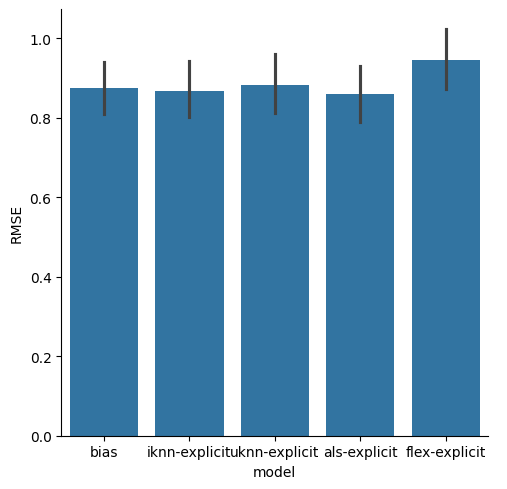

In [18]:
pred_metrics = pred_results.list_metrics().reset_index()
pred_metrics = pred_metrics[pred_metrics['user_id'].isin(train_users.index)]
sns.catplot(pred_metrics, x='model', y='RMSE', kind='bar')
plt.show()

## Save Metrics

We'll now save the metrics to a file.

In [19]:
rlsum = rec_results.list_summary('model')['mean'].unstack()
rlsum

/home/mde48/lenskit/lk-demo-experiment/.venv/lib/python3.12/site-packages/lenskit/metrics/bulk.py:92: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df = scores.groupby(list(keys)).agg(["mean", "median", "std"]).stack(level=0)


,NDCG,RBP,RecipRank
model,,,
als-explicit,0.163501,0.176019,0.239936
als-implicit,0.099538,0.046578,0.103273
bias,0.163369,0.177391,0.228765
flex-bpr,0.068223,0.029506,0.069638
flex-explicit,0.068379,0.026615,0.070937
flex-logistic,0.068177,0.028096,0.064493
flex-warp,0.068526,0.030376,0.070343
iknn-explicit,0.027915,0.014224,0.036419
iknn-implicit,0.051237,0.045462,0.077597


In [20]:
rlsum.to_json(f'eval-metrics.{dataset}.json', orient='index')